In [ ]:
import numpy as np
import pandas as pd 
import os
os.chdir('..')  # Go up to project root
import matplotlib.pyplot as plt
from scipy import stats
import pyarrow.parquet as pq
import seaborn as sns
for dirname, _, filenames in os.walk('./kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

./kaggle/input/broad-peak.csv
./kaggle/input/lhotse.csv
./kaggle/input/kangchenjunga.csv
./kaggle/input/.DS_Store
./kaggle/input/cho-oyu.csv
./kaggle/input/everest_20-25.csv
./kaggle/input/manaslu.csv
./kaggle/input/dhaulagiri-I.csv
./kaggle/input/EVER.parquet
./kaggle/input/everest.csv
./kaggle/input/k2.csv
./kaggle/input/nanga-parbat.csv
./kaggle/input/gasherbrum-II.csv
./kaggle/input/shishapangma.csv
./kaggle/input/gasherbrum-I.csv
./kaggle/input/annapurna-I.csv
./kaggle/input/makalu.csv


In [2]:
everest20_25 = pd.read_csv('./kaggle/input/everest_20-25.csv')
everesttemps = pd.read_parquet('./kaggle/input/EVER.parquet')

In [3]:
everesttemps.head()

,peakid,date,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,wind_speed_100m,wind_direction_100m,weather_code,surface_pressure,et0_fao_evapotranspiration,vapour_pressure_deficit,snow_depth,shortwave_radiation,direct_radiation,diffuse_radiation
0,EVER,1980-01-01 00:00:00+00:00,-42.257999,65.533333,0.1,0.0,0.07,10.495713,247.833603,71,320.562103,0.000000,0.005050,26.72,0.0,0.0,0.0
1,EVER,1980-01-01 01:00:00+00:00,-43.307999,65.239151,0.1,0.0,0.07,9.904906,250.906403,71,319.143005,0.000000,0.004547,26.72,0.0,0.0,0.0
2,EVER,1980-01-01 02:00:00+00:00,-43.407997,65.210953,0.0,0.0,0.07,9.565437,250.201035,71,319.249481,0.001487,0.004501,26.72,69.0,43.0,26.0
3,EVER,1980-01-01 03:00:00+00:00,-42.858002,64.642563,0.0,0.0,0.07,8.699793,245.556061,71,320.421326,0.009074,0.004856,26.72,290.0,218.0,72.0
4,EVER,1980-01-01 04:00:00+00:00,-40.757999,60.427090,0.0,0.0,0.07,9.290511,234.462234,71,323.635406,0.020720,0.006801,26.72,504.0,410.0,94.0


In [4]:
# First, convert date to just date (no time)
everesttemps['date_only'] = pd.to_datetime(everesttemps['date']).dt.date

# Group by date and aggregate
# Use mode for categorical/weather columns, mean for numerical measurements
daily_everest = everesttemps.groupby('date_only').agg({
    'peakid': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0],  # Mode
    'temperature_2m': 'mean',  # Average temperature
    'relative_humidity_2m': 'mean',  # Average humidity
    'precipitation': 'sum',  # Total precipitation
    'rain': 'sum',  # Total rain
    'snowfall': 'sum',  # Total snowfall
    'wind_speed_100m': 'mean',  # Average wind speed
    'wind_direction_100m': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0],  # Mode
    'weather_code': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0],  # Mode
    'surface_pressure': 'mean',  # Average pressure
    'et0_fao_evapotranspiration': 'sum',  # Total evapotranspiration
    'vapour_pressure_deficit': 'mean',  # Average VPD
    'snow_depth': 'mean',  # Average snow depth
    'shortwave_radiation': 'sum',  # Total radiation
    'direct_radiation': 'sum',  # Total direct radiation
    'diffuse_radiation': 'sum'  # Total diffuse radiation
}).reset_index()

print(f"Original dataset: {len(everesttemps)} rows (hourly)")
print(f"Aggregated dataset: {len(daily_everest)} rows (daily)")
print(daily_everest.head())

Original dataset: 394488 rows (hourly)
Aggregated dataset: 16437 rows (daily)
    date_only peakid  temperature_2m  relative_humidity_2m  precipitation  \
0  1980-01-01   EVER      -41.080914             61.184116            4.2   
1  1980-01-02   EVER      -43.249664             25.218580            2.0   
2  1980-01-03   EVER      -44.057999             11.458504            0.5   
3  1980-01-04   EVER      -42.401749              6.349964            0.0   
4  1980-01-05   EVER      -42.583000              6.322521            0.6   

   rain  snowfall  wind_speed_100m  wind_direction_100m  weather_code  \
0   0.0      3.36        11.182387           234.462234            71   
1   0.0      1.82        12.834381           228.366547            71   
2   0.0      1.68        11.404770           232.431335            71   
3   0.0      1.61        10.690829           236.309906            71   
4   0.0      1.61         9.154526           236.309906            71   

   surface_pressure 

In [5]:
# Convert both to the same datetime format (no .date())
everest20_25['Date'] = pd.to_datetime(everest20_25['Date'])
daily_everest['date_only'] = pd.to_datetime(daily_everest['date_only'])

In [6]:
# Now merge
everest_with_weather = everest20_25.merge(
    daily_everest, 
    left_on='Date', 
    right_on='date_only', 
    how='left'
)

print(f"Original everest20_25: {len(everest20_25)} rows")
print(f"After merge: {len(everest_with_weather)} rows")
print(f"Rows with weather data: {everest_with_weather['temperature_2m'].notna().sum()}")
print("\nSample:")
print(everest_with_weather[['Date', 'Name', 'temperature_2m', 'wind_speed_100m']].head())

Original everest20_25: 500 rows
After merge: 500 rows
Rows with weather data: 430

Sample:
        Date              Name  temperature_2m  wind_speed_100m
0 2020-04-30        Yuki Kumar      -30.519251         3.634366
1 2020-12-08     Barbara Popov      -37.548416        11.715946
2 2021-01-26  Alessandro Singh      -44.354671        23.488352
3 2021-06-03        Robert Ito      -24.690084         8.117670
4 2021-09-04        Paul Scott      -21.515083         2.926442


In [7]:
everest_with_weather.head()

,Date,Name,Nationality,Age,Gender,Cause_of_Death,Altitude_meters,Location,Location_in_Meters,Location_Order,...,wind_speed_100m,wind_direction_100m,weather_code,surface_pressure,et0_fao_evapotranspiration,vapour_pressure_deficit,snow_depth,shortwave_radiation,direct_radiation,diffuse_radiation
0,2020-04-30,Yuki Kumar,Norway,45,Female,Falling,6065,Base Camp,5364m,1,...,3.634366,18.435053,3.0,339.890167,1.240361,0.011794,26.732917,9381.0,8011.0,1370.0
1,2020-12-08,Barbara Popov,Denmark,66,Male,Rockfall,6065,Base Camp,5364m,1,...,11.715946,270.000000,0.0,330.999664,0.369900,0.012836,26.660000,5159.0,4501.0,658.0
2,2021-01-26,Alessandro Singh,Switzerland,28,Male,Altitude Sickness (AMS/HAPE/HACE),8000,Base Camp,5364m,1,...,23.488352,240.592896,0.0,319.658539,0.172183,0.008700,26.660000,6002.0,5396.0,606.0
3,2021-06-03,Robert Ito,United Kingdom,26,Male,Altitude Sickness (AMS/HAPE/HACE),8000,Base Camp,5364m,1,...,8.117670,229.398788,0.0,347.242340,1.676511,0.036803,26.696250,9234.0,6890.0,2344.0
4,2021-09-04,Paul Scott,Switzerland,22,Male,Crevasse fall,8750,Base Camp,5364m,1,...,2.926442,239.036301,3.0,350.959625,1.596249,0.008816,26.712500,7330.0,4948.0,2382.0


In [8]:
# 1. Weather Conditions on Death Days vs Normal Days
print("WEATHER ON DEATH DAYS")
print("=" * 80)
print(f"Average temperature on death days: {everest_with_weather['temperature_2m'].mean():.1f}°C")
print(f"Average wind speed on death days: {everest_with_weather['wind_speed_100m'].mean():.1f} m/s")
print(f"Average precipitation on death days: {everest_with_weather['precipitation'].mean():.2f} mm")
print(f"Average snowfall on death days: {everest_with_weather['snowfall'].mean():.1f} cm")

WEATHER ON DEATH DAYS
Average temperature on death days: -31.3°C
Average wind speed on death days: 10.9 m/s
Average precipitation on death days: 1.26 mm
Average snowfall on death days: 0.9 cm


In [9]:
# 2. Weather by Cause of Death
print("\n\nWEATHER CONDITIONS BY CAUSE OF DEATH")
print("=" * 80)
weather_by_cause = everest_with_weather.groupby('Cause_of_Death').agg({
    'temperature_2m': 'mean',
    'wind_speed_100m': 'mean',
    'precipitation': 'mean',
    'snowfall': 'mean',
    'weather_code': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'N/A'
}).round(2)
print(weather_by_cause)



WEATHER CONDITIONS BY CAUSE OF DEATH
                                   temperature_2m  wind_speed_100m  \
Cause_of_Death                                                       
Altitude Sickness (AMS/HAPE/HACE)      -30.430000        10.560000   
Avalanche                              -32.950001        11.300000   
Cerebral edema                         -30.150000        10.610000   
Crevasse fall                          -32.500000        13.240000   
Disorientation/Lost                    -28.450001        11.630000   
Equipment failure                      -32.450001        16.629999   
Exhaustion                             -31.610001        10.930000   
Falling                                -32.410000         9.860000   
Frostbite complications                -31.330000        11.310000   
Hypothermia                            -30.620001        11.180000   
Icefall                                -30.940001        10.070000   
Pulmonary edema                        -30.590000  

In [10]:
# 3. Extreme Weather Deaths
print("\n\nEXTREME WEATHER ANALYSIS")
print("=" * 80)
# Define extreme conditions
extreme_cold = everest_with_weather[everest_with_weather['temperature_2m'] < -40]
extreme_wind = everest_with_weather[everest_with_weather['wind_speed_100m'] > 30]
heavy_precip = everest_with_weather[everest_with_weather['precipitation'] > 5]

print(f"Deaths in extreme cold (<-40°C): {len(extreme_cold)} ({len(extreme_cold)/len(everest_with_weather)*100:.1f}%)")
print(f"Deaths in extreme wind (>30 m/s): {len(extreme_wind)} ({len(extreme_wind)/len(everest_with_weather)*100:.1f}%)")
print(f"Deaths with heavy precipitation (>5mm): {len(heavy_precip)} ({len(heavy_precip)/len(everest_with_weather)*100:.1f}%)")




EXTREME WEATHER ANALYSIS
Deaths in extreme cold (<-40°C): 91 (18.2%)
Deaths in extreme wind (>30 m/s): 9 (1.8%)
Deaths with heavy precipitation (>5mm): 30 (6.0%)


In [11]:
# 4. Weather vs Experience Level
print("\n\nWEATHER BY EXPERIENCE LEVEL")
print("=" * 80)
weather_by_exp = everest_with_weather.groupby('Experience_Level').agg({
    'temperature_2m': 'mean',
    'wind_speed_100m': 'mean',
    'precipitation': 'mean',
    'snowfall': 'mean',
}).round(2)
print(weather_by_exp)



WEATHER BY EXPERIENCE LEVEL
                    temperature_2m  wind_speed_100m  precipitation  snowfall
Experience_Level                                                            
Experienced             -30.930000            11.69           1.03      0.69
Expert                  -31.549999            10.65           1.53      1.06
Intermediate            -32.439999            12.36           1.18      0.80
Novice                  -29.870001            10.38           0.95      0.64
Professional Guide      -31.450001            10.79           1.70      1.18
Sherpa                  -31.990000             9.78           1.25      0.87


In [12]:
# 5. Correlation: Weather vs Altitude of Death
print("\n\nCORRELATION: WEATHER VS ALTITUDE")
print("=" * 80)
weather_cols = ['temperature_2m', 'wind_speed_100m', 'precipitation', 'snowfall']
correlations = everest_with_weather[weather_cols + ['Altitude_meters']].corr()['Altitude_meters'].drop('Altitude_meters')
print(correlations.sort_values(ascending=False))



CORRELATION: WEATHER VS ALTITUDE
wind_speed_100m    0.056434
precipitation      0.026778
snowfall           0.025936
temperature_2m     0.008321
Name: Altitude_meters, dtype: float64


In [13]:
# 6. Most Dangerous Weather Combinations
print("\n\nMOST DANGEROUS WEATHER CONDITIONS")
print("=" * 80)
# Create weather severity score
everest_with_weather['weather_severity'] = (
    (everest_with_weather['temperature_2m'] < -35).astype(int) +  # Extreme cold
    (everest_with_weather['wind_speed_100m'] > 25).astype(int) +  # High wind
    (everest_with_weather['precipitation'] > 2).astype(int)        # Precipitation
)
print(everest_with_weather['weather_severity'].value_counts().sort_index())
print(f"\nDeaths with 2+ severe conditions: {(everest_with_weather['weather_severity'] >= 2).sum()}")




MOST DANGEROUS WEATHER CONDITIONS
weather_severity
0    275
1    191
2     32
3      2
Name: count, dtype: int64

Deaths with 2+ severe conditions: 34


In [14]:
# 8. Temperature Ranges
print("\n\nTEMPERATURE DISTRIBUTION ON DEATH DAYS")
print("=" * 80)
temp_bins = pd.cut(everest_with_weather['temperature_2m'], 
                   bins=[-60, -45, -40, -35, -30, -25, 0],
                   labels=['< -45°C', '-45 to -40°C', '-40 to -35°C', '-35 to -30°C', '-30 to -25°C', '> -25°C'])
print(temp_bins.value_counts().sort_index())



TEMPERATURE DISTRIBUTION ON DEATH DAYS
temperature_2m
< -45°C          17
-45 to -40°C     74
-40 to -35°C     84
-35 to -30°C     60
-30 to -25°C     51
> -25°C         144
Name: count, dtype: int64


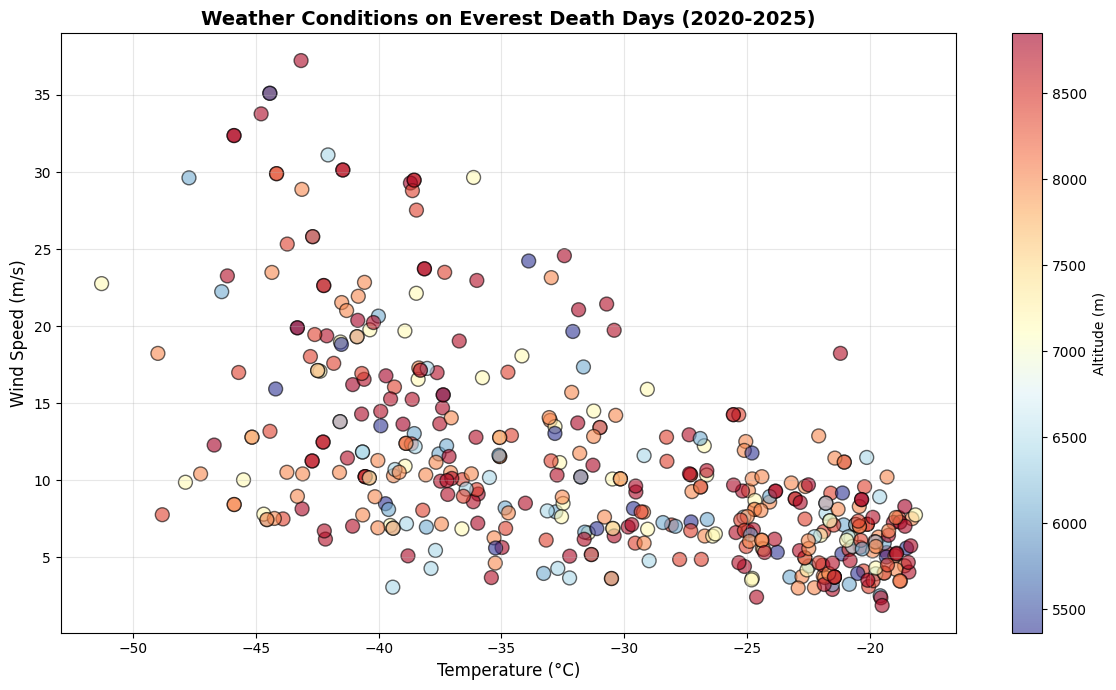

In [15]:
# 1. Temperature vs Wind Speed on Death Days
plt.figure(figsize=(12, 7))
scatter = plt.scatter(everest_with_weather['temperature_2m'], 
                     everest_with_weather['wind_speed_100m'],
                     c=everest_with_weather['Altitude_meters'],
                     cmap='RdYlBu_r',
                     s=100,
                     alpha=0.6,
                     edgecolors='black')
plt.colorbar(scatter, label='Altitude (m)')
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Wind Speed (m/s)', fontsize=12)
plt.title('Weather Conditions on Everest Death Days (2020-2025)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save plot
plt.savefig('images/everest_weather_deaths_scatter.png', dpi=300, bbox_inches='tight')
plt.show()


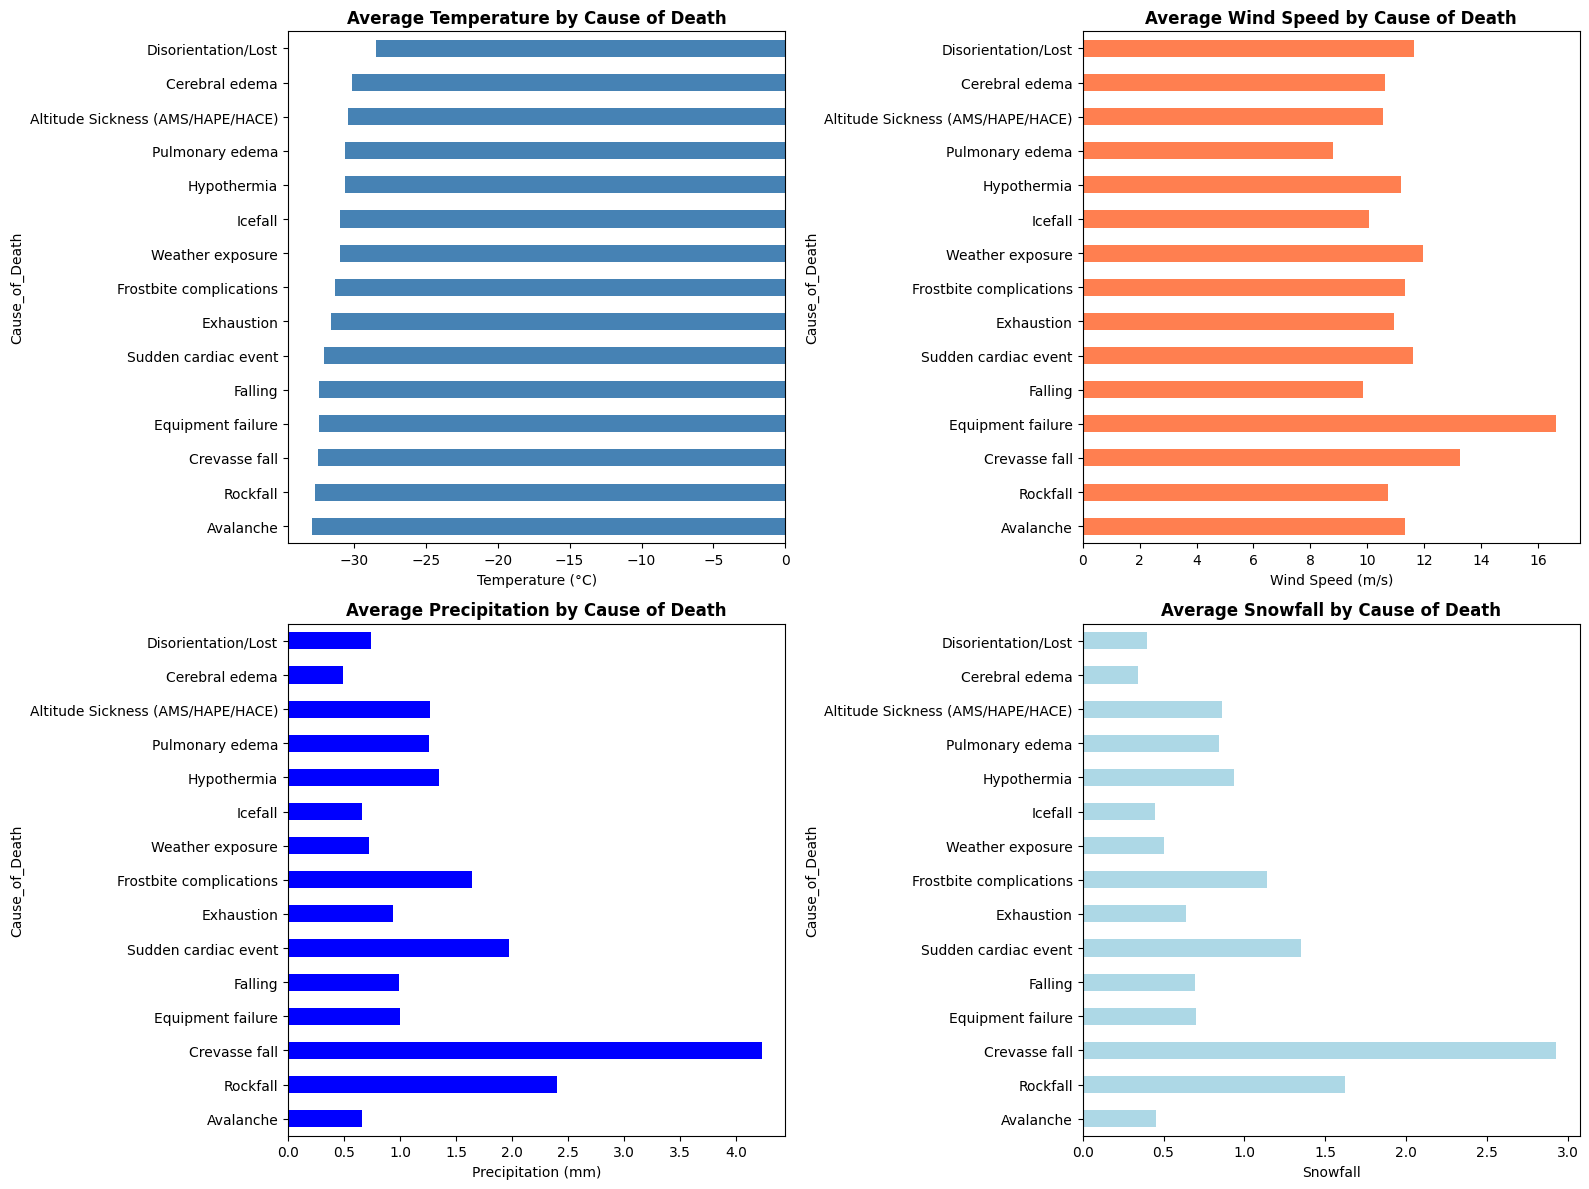

In [16]:
# 2. Weather by Cause of Death
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Temperature by cause
cause_weather = everest_with_weather.groupby('Cause_of_Death').agg({
    'temperature_2m': 'mean',
    'wind_speed_100m': 'mean',
    'precipitation': 'mean',
    'snowfall': 'mean',
}).sort_values('temperature_2m')

cause_weather['temperature_2m'].plot(kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Average Temperature by Cause of Death', fontweight='bold')
axes[0,0].set_xlabel('Temperature (°C)')

cause_weather['wind_speed_100m'].plot(kind='barh', ax=axes[0,1], color='coral')
axes[0,1].set_title('Average Wind Speed by Cause of Death', fontweight='bold')
axes[0,1].set_xlabel('Wind Speed (m/s)')

cause_weather['precipitation'].plot(kind='barh', ax=axes[1,0], color='blue')
axes[1,0].set_title('Average Precipitation by Cause of Death', fontweight='bold')
axes[1,0].set_xlabel('Precipitation (mm)')

cause_weather['snowfall'].plot(kind='barh', ax=axes[1,1], color='lightblue')
axes[1,1].set_title('Average Snowfall by Cause of Death', fontweight='bold')
axes[1,1].set_xlabel('Snowfall')

plt.tight_layout()

# Save plot
plt.savefig('images/everest_weather_by_cause.png', dpi=300, bbox_inches='tight')
plt.show()

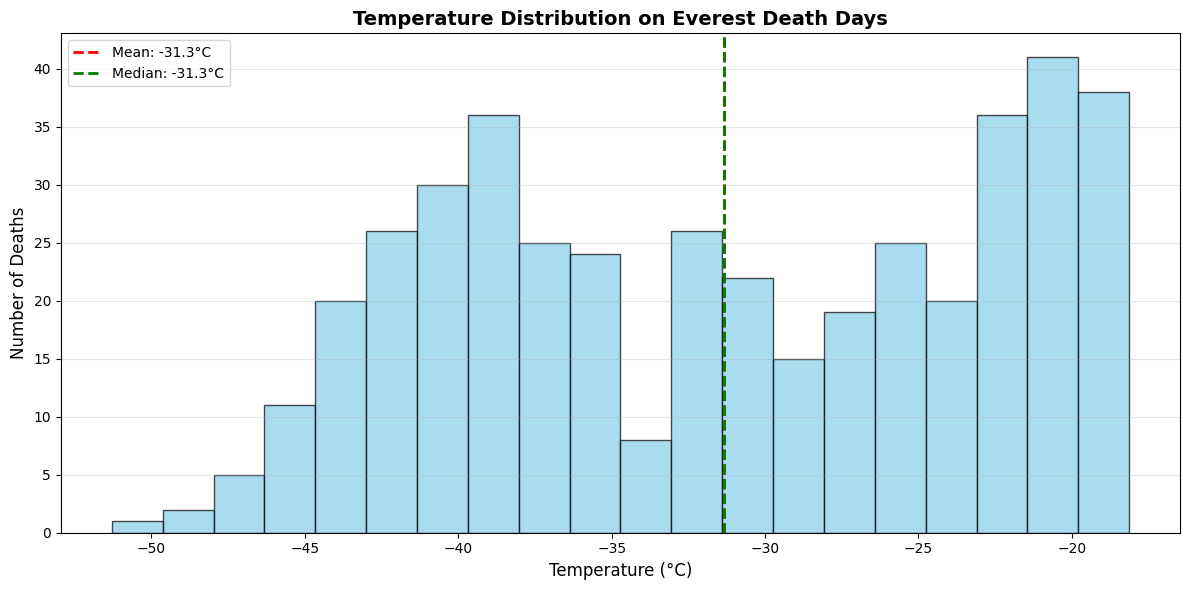

In [17]:
# 3. Temperature Distribution
plt.figure(figsize=(12, 6))
plt.hist(everest_with_weather['temperature_2m'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(everest_with_weather['temperature_2m'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {everest_with_weather["temperature_2m"].mean():.1f}°C')
plt.axvline(everest_with_weather['temperature_2m'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {everest_with_weather["temperature_2m"].median():.1f}°C')
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Number of Deaths', fontsize=12)
plt.title('Temperature Distribution on Everest Death Days', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

# Save plot
plt.savefig('images/everest_temperature_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

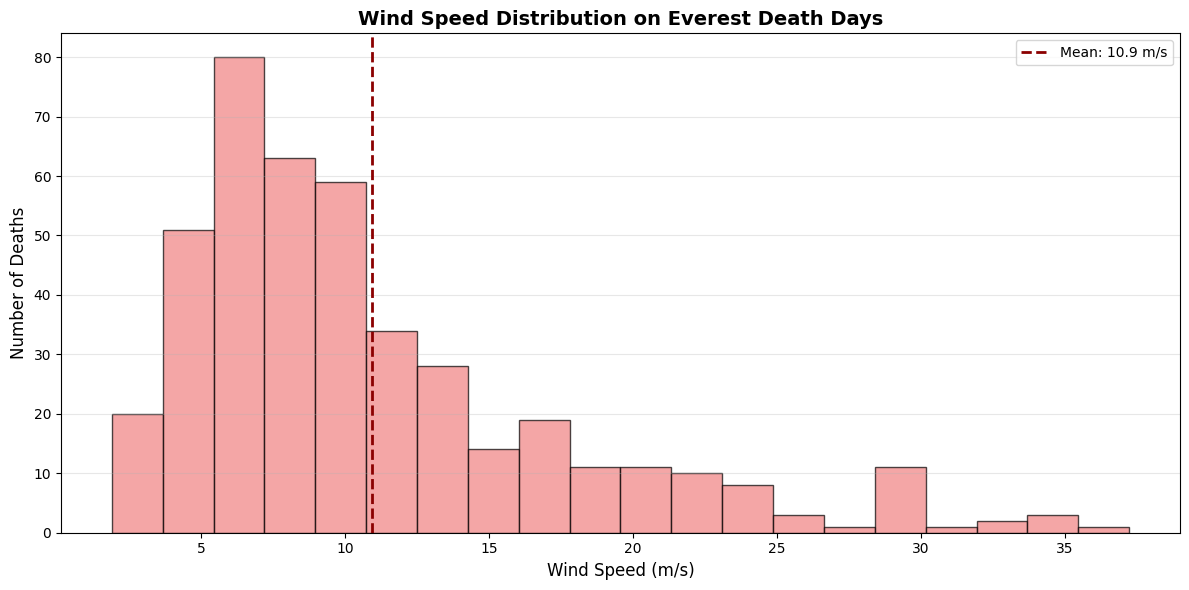

In [18]:
# 4. Wind Speed Distribution
plt.figure(figsize=(12, 6))
plt.hist(everest_with_weather['wind_speed_100m'], bins=20, color='lightcoral', edgecolor='black', alpha=0.7)
plt.axvline(everest_with_weather['wind_speed_100m'].mean(), color='darkred', linestyle='--', linewidth=2, label=f'Mean: {everest_with_weather["wind_speed_100m"].mean():.1f} m/s')
plt.xlabel('Wind Speed (m/s)', fontsize=12)
plt.ylabel('Number of Deaths', fontsize=12)
plt.title('Wind Speed Distribution on Everest Death Days', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

# Save plot
plt.savefig('images/everest_wind_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

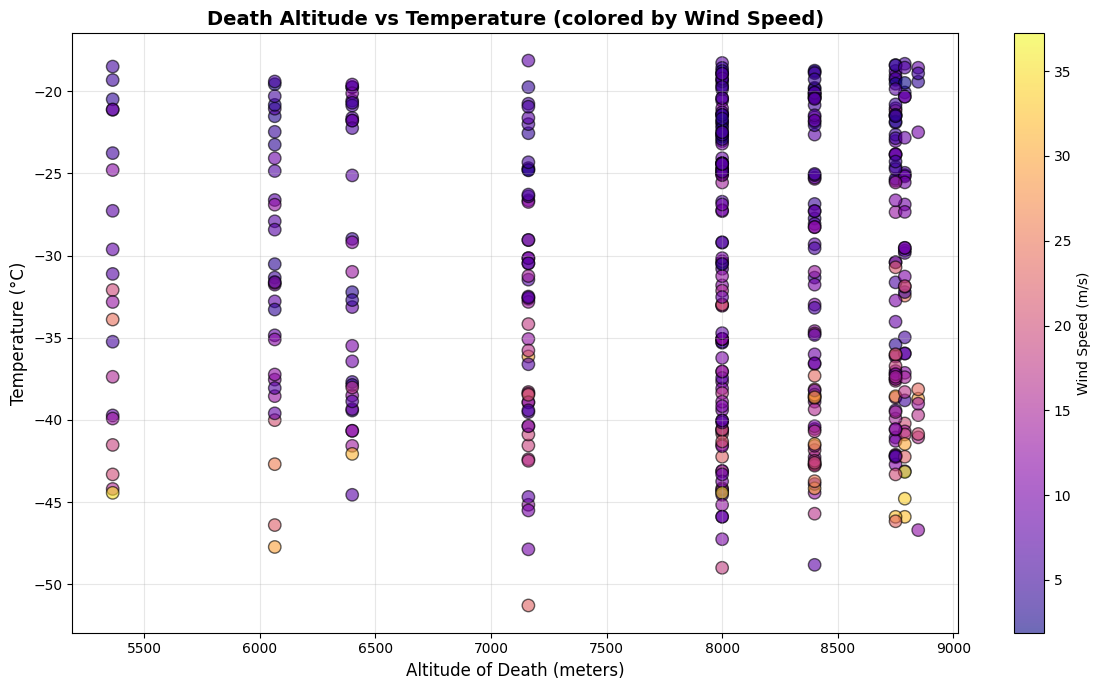

In [19]:
# 5. Altitude vs Temperature
plt.figure(figsize=(12, 7))
plt.scatter(everest_with_weather['Altitude_meters'], 
           everest_with_weather['temperature_2m'],
           alpha=0.6,
           s=80,
           c=everest_with_weather['wind_speed_100m'],
           cmap='plasma',
           edgecolors='black')
plt.colorbar(label='Wind Speed (m/s)')
plt.xlabel('Altitude of Death (meters)', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.title('Death Altitude vs Temperature (colored by Wind Speed)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save plot
plt.savefig('images/everest_altitude_temp_wind.png', dpi=300, bbox_inches='tight')
plt.show()

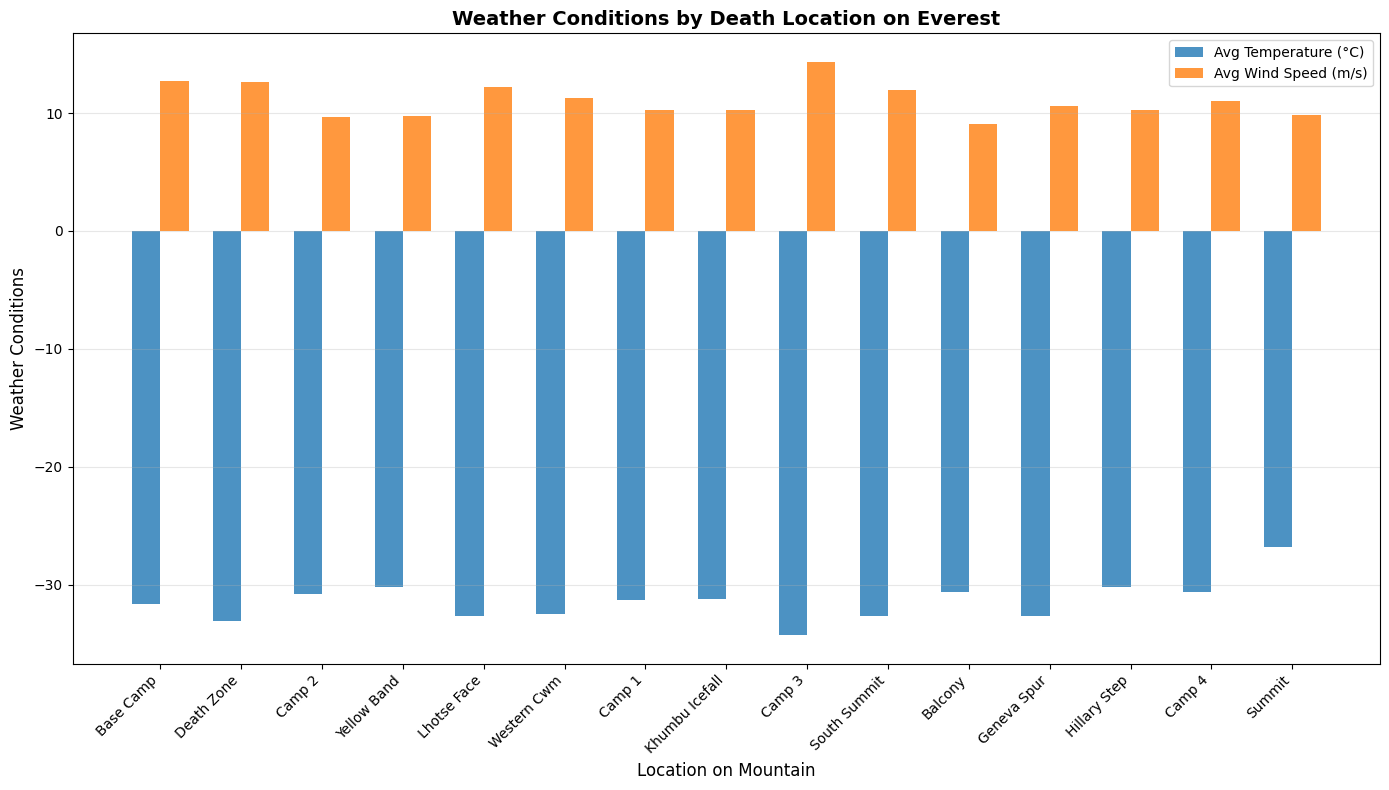

In [20]:
# Weather severity map by location
location_weather = everest_with_weather.groupby('Location').agg({
    'temperature_2m': 'mean',
    'wind_speed_100m': 'mean',
    'Altitude_meters': 'mean'
}).sort_values('Altitude_meters')

plt.figure(figsize=(14, 8))
x = range(len(location_weather))
width = 0.35

plt.bar([i - width/2 for i in x], location_weather['temperature_2m'], width, 
        label='Avg Temperature (°C)', alpha=0.8)
plt.bar([i + width/2 for i in x], location_weather['wind_speed_100m'], width,
        label='Avg Wind Speed (m/s)', alpha=0.8)

plt.xlabel('Location on Mountain', fontsize=12)
plt.ylabel('Weather Conditions', fontsize=12)
plt.title('Weather Conditions by Death Location on Everest', fontsize=14, fontweight='bold')
plt.xticks(x, location_weather.index, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

# Save plot
plt.savefig('images/everest_location_weather.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
# 1. Deaths by Location Order (Ascending the Mountain) - Drop NaN altitudes
location_deaths = everest_with_weather.groupby('Location_Order').agg({
    'Location_Order': 'first',
    'Location': 'first',
    'Location_in_Meters': 'first'
}).reset_index(drop=True)

# Count deaths per location
death_counts = everest_with_weather.groupby('Location_Order').size().reset_index(name='deaths')
location_deaths = location_deaths.merge(death_counts, on='Location_Order')

# Drop rows with missing altitude data
location_deaths = location_deaths.dropna(subset=['Location_in_Meters'])

print("DEATHS BY LOCATION (ASCENDING ORDER)")
print("=" * 80)
print(location_deaths.sort_values('Location_Order'))

DEATHS BY LOCATION (ASCENDING ORDER)
    Location_Order        Location Location_in_Meters  deaths
0                1       Base Camp              5364m      23
1                2  Khumbu Icefall              5486m      49
2                3          Camp 1              6065m      33
3                4     Western Cwm              6200m      41
4                5          Camp 2              6400m      38
5                6     Lhotse Face              7000m      30
6                7          Camp 3              7162m      27
7                8     Yellow Band              7700m      35
8                9     Geneva Spur              7800m      22
9               10          Camp 4              8000m      41
10              11      Death Zone              8200m      31
11              12         Balcony              8400m      35
12              13    South Summit              8750m      36
13              14    Hillary Step              8790m      27
14              15          Summi

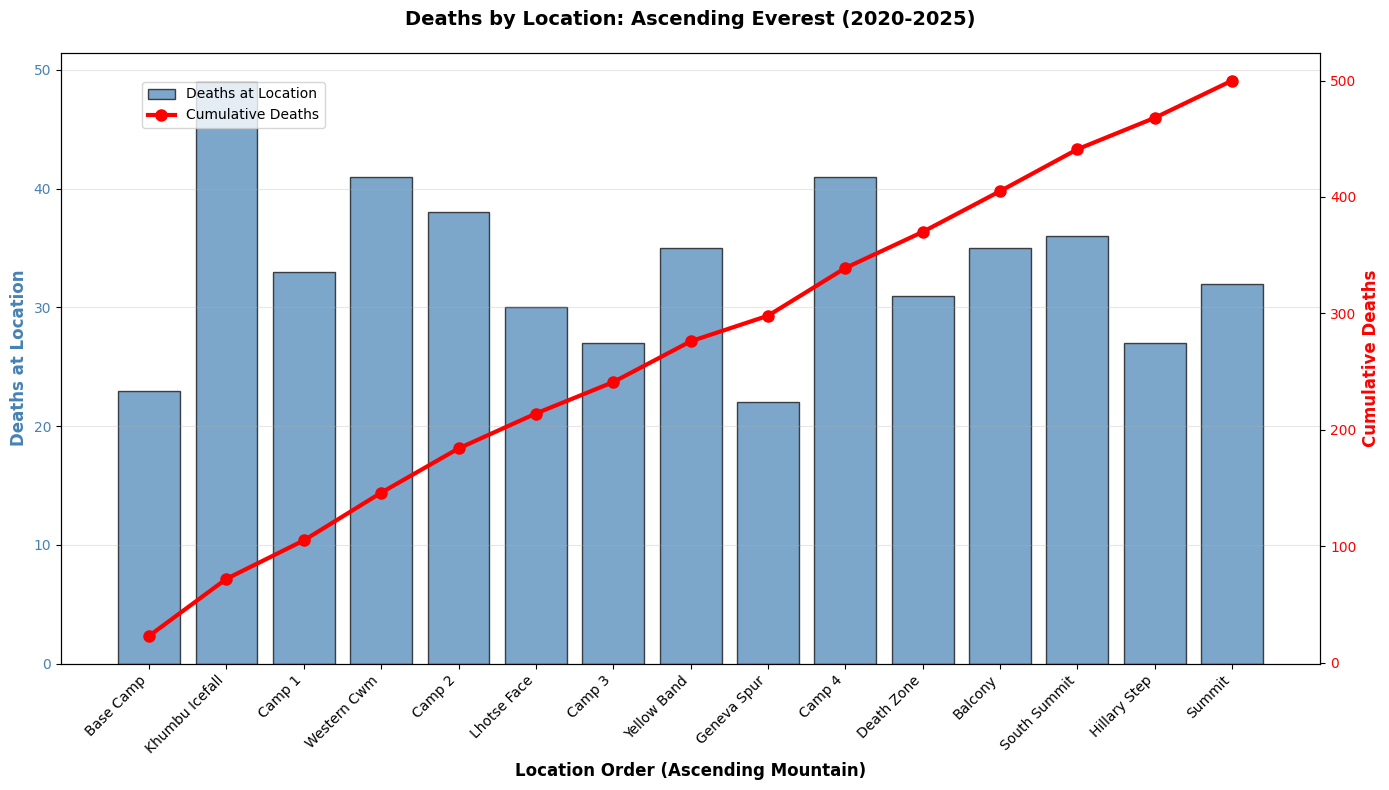

In [23]:
# 3. Cumulative Deaths as You Climb
location_deaths_sorted = location_deaths.sort_values('Location_Order')
location_deaths_sorted['cumulative_deaths'] = location_deaths_sorted['deaths'].cumsum()

fig, ax1 = plt.subplots(figsize=(14, 8))

# Bar chart of deaths at each location
ax1.bar(range(len(location_deaths_sorted)), 
        location_deaths_sorted['deaths'].values,
        color='steelblue',
        alpha=0.7,
        edgecolor='black',
        label='Deaths at Location')
ax1.set_xlabel('Location Order (Ascending Mountain)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Deaths at Location', fontsize=12, fontweight='bold', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Line chart of cumulative deaths
ax2 = ax1.twinx()
ax2.plot(range(len(location_deaths_sorted)), 
         location_deaths_sorted['cumulative_deaths'].values,
         color='red',
         marker='o',
         linewidth=3,
         markersize=8,
         label='Cumulative Deaths')
ax2.set_ylabel('Cumulative Deaths', fontsize=12, fontweight='bold', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# X-axis labels with location names
ax1.set_xticks(range(len(location_deaths_sorted)))
ax1.set_xticklabels(location_deaths_sorted['Location'].values, rotation=45, ha='right')

plt.title('Deaths by Location: Ascending Everest (2020-2025)', 
          fontsize=14, fontweight='bold', pad=20)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
ax1.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('images/everest_cumulative_deaths_climb.png', dpi=300, bbox_inches='tight')
plt.show()


Checking Location_in_Meters data:
           Location  Location_in_Meters
0         Base Camp                5364
23   Khumbu Icefall                5486
72           Camp 1                6065
105     Western Cwm                6200
146          Camp 2                6400
184     Lhotse Face                7000
214          Camp 3                7162
241     Yellow Band                7700
276     Geneva Spur                7800
298          Camp 4                8000
339      Death Zone                8200
370         Balcony                8400
405    South Summit                8750
441    Hillary Step                8790
468          Summit                8848

Data type: int64

Location deaths data:
    Location_Order        Location  Location_in_Meters  deaths
0                1       Base Camp                5364      23
1                2  Khumbu Icefall                5486      49
2                3          Camp 1                6065      33
3                4     Western Cw

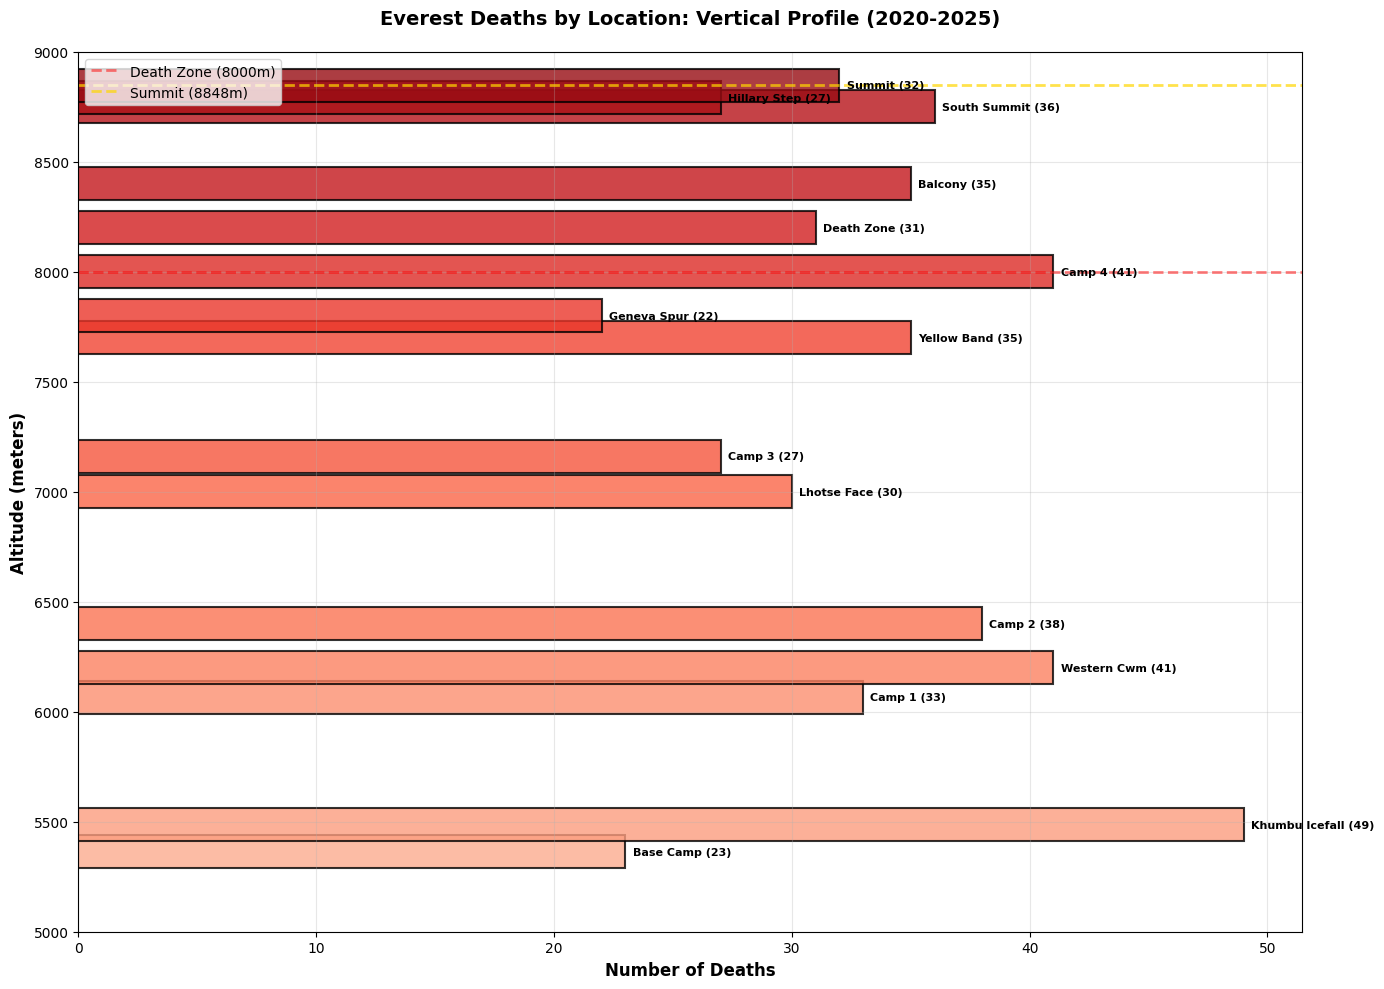


DEATHS BEFORE VS IN DEATH ZONE

Total deaths below Death Zone (<8000m): 298
Total deaths in Death Zone (≥8000m): 202
Percentage in Death Zone: 40.4%

--------------------------------------------------------------------------------
DEATHS BELOW DEATH ZONE (<8000m)
--------------------------------------------------------------------------------
Yuki Kumar                     | Base Camp                      | 5364m | Falling
Barbara Popov                  | Base Camp                      | 5364m | Rockfall
Alessandro Singh               | Base Camp                      | 5364m | Altitude Sickness (AMS/HAPE/HACE)
Robert Ito                     | Base Camp                      | 5364m | Altitude Sickness (AMS/HAPE/HACE)
Paul Scott                     | Base Camp                      | 5364m | Crevasse fall
Michael Thomas                 | Base Camp                      | 5364m | Exhaustion
Emily Lopez                    | Base Camp                      | 5364m | Crevasse fall
Charles Gupt

In [33]:
# Check the data first
print("Checking Location_in_Meters data:")
print(everest_with_weather[['Location', 'Location_in_Meters']].drop_duplicates())
print(f"\nData type: {everest_with_weather['Location_in_Meters'].dtype}")

# Remove 'm' and convert to numeric
everest_with_weather['Location_in_Meters'] = everest_with_weather['Location_in_Meters'].astype(str).str.replace('m', '').str.strip()
everest_with_weather['Location_in_Meters'] = pd.to_numeric(everest_with_weather['Location_in_Meters'], errors='coerce')

# Now recreate location_deaths with proper numeric altitudes
location_deaths = everest_with_weather.groupby('Location_Order').agg({
    'Location': 'first',
    'Location_in_Meters': 'first'
}).reset_index()

# Count deaths per location
death_counts = everest_with_weather.groupby('Location_Order').size().reset_index(name='deaths')
location_deaths = location_deaths.merge(death_counts, on='Location_Order')

# Drop rows with missing altitude data
location_deaths = location_deaths.dropna(subset=['Location_in_Meters'])

print("\nLocation deaths data:")
print(location_deaths.sort_values('Location_in_Meters'))

# 2. Vertical Profile Visualization
fig, ax = plt.subplots(figsize=(14, 10))

# Create vertical bars at each location
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(location_deaths)))

for idx, row in location_deaths.iterrows():
    altitude = float(row['Location_in_Meters'])  # Ensure it's a float
    
    # Horizontal bar showing deaths at this altitude
    ax.barh(altitude, row['deaths'], 
            height=150,  # Bar height (altitude range)
            left=0,
            color=colors[idx],
            edgecolor='black',
            linewidth=1.5,
            alpha=0.8)
    
    # Label with location name and death count
    ax.text(row['deaths'] + 0.3, altitude, 
            f"{row['Location']} ({row['deaths']})",
            va='center',
            fontsize=8,
            fontweight='bold')

# Add reference lines
ax.axhline(8000, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Death Zone (8000m)')
ax.axhline(8849, color='gold', linestyle='--', linewidth=2, alpha=0.7, label='Summit (8848m)')

# Set y-axis limits to show full mountain range
ax.set_ylim(5000, 9000)

ax.set_xlabel('Number of Deaths', fontsize=12, fontweight='bold')
ax.set_ylabel('Altitude (meters)', fontsize=12, fontweight='bold')
ax.set_title('Everest Deaths by Location: Vertical Profile (2020-2025)', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Save plot
plt.savefig('images/everest_death_vertical_profile.png', dpi=300, bbox_inches='tight')
plt.show()

# After the plot, add this analysis:

print("\n" + "=" * 80)
print("DEATHS BEFORE VS IN DEATH ZONE")
print("=" * 80)

# Split deaths by Death Zone (8000m)
below_death_zone = everest_with_weather[everest_with_weather['Location_in_Meters'] < 8000]
in_death_zone = everest_with_weather[everest_with_weather['Location_in_Meters'] >= 8000]

print(f"\nTotal deaths below Death Zone (<8000m): {len(below_death_zone)}")
print(f"Total deaths in Death Zone (≥8000m): {len(in_death_zone)}")
print(f"Percentage in Death Zone: {len(in_death_zone)/len(everest_with_weather)*100:.1f}%")

print("\n" + "-" * 80)
print("DEATHS BELOW DEATH ZONE (<8000m)")
print("-" * 80)
for idx, row in below_death_zone.iterrows():
    print(f"{row['Name']:30s} | {row['Location']:30s} | {row['Location_in_Meters']:.0f}m | {row['Cause_of_Death']}")

print("\n" + "-" * 80)
print("DEATHS IN DEATH ZONE (≥8000m)")
print("-" * 80)
for idx, row in in_death_zone.iterrows():
    print(f"{row['Name']:30s} | {row['Location']:30s} | {row['Location_in_Meters']:.0f}m | {row['Cause_of_Death']}")

# Summary by location
print("\n" + "=" * 80)
print("SUMMARY BY LOCATION")
print("=" * 80)

print("\nBELOW DEATH ZONE:")
below_summary = below_death_zone.groupby('Location').agg({
    'Name': 'count',
    'Location_in_Meters': 'first'
}).rename(columns={'Name': 'Deaths'}).sort_values('Location_in_Meters')
print(below_summary)

print("\nIN DEATH ZONE:")
in_summary = in_death_zone.groupby('Location').agg({
    'Name': 'count',
    'Location_in_Meters': 'first'
}).rename(columns={'Name': 'Deaths'}).sort_values('Location_in_Meters')
print(in_summary)